In [1]:
# Install scikit uplift
%pip install scikit-uplift
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [63]:
# Core packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional visualization package
# If seaborn is not installed, run:
# pip install seaborn
import seaborn as sns

# Hillstrom dataset
from sklift.datasets import fetch_hillstrom

# sklearn preprocessing tools
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Reproducibility
np.random.seed(42)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")


# ============================================================
# 1. LOAD THE HILLSTROM DATASET
# ============================================================

hillstrom = fetch_hillstrom(target_col="all")

# Historical / pre-campaign customer features
X = hillstrom.data.copy()

# Post-campaign outcomes:
# visit, conversion, spend
y = hillstrom.target.copy()

# Randomized campaign assignment
treatment = hillstrom.treatment.copy()

print("Features:")
display(X.head())

print("\nOutcomes:")
display(y.head())

print("\nTreatment:")
display(treatment.head())


Features:


,recency,history_segment,history,mens,womens,zip_code,newbie,channel
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web



Outcomes:


,visit,conversion,spend
0,0,0,0.0
1,0,0,0.0
2,0,0,0.0
3,0,0,0.0
4,0,0,0.0



Treatment:


0    Womens E-Mail
1        No E-Mail
2    Womens E-Mail
3      Mens E-Mail
4    Womens E-Mail
Name: segment, dtype: str

In [64]:
# ============================================================
# 2. CREATE MASTER ANALYSIS DATAFRAME
# ============================================================

hillstrom_df = pd.concat(
    [
        X.reset_index(drop=True),
        treatment.rename("treatment").reset_index(drop=True),
        y.reset_index(drop=True)
    ],
    axis=1
)

print("First 10 rows:")
display(hillstrom_df.head(10))


print("Dataset shape:", hillstrom_df.shape)
print(f"Rows: {hillstrom_df.shape[0]:,}")
print(f"Columns: {hillstrom_df.shape[1]}")

First 10 rows:


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0
5,6,2) $100 - $200,134.83,0,1,Surburban,0,Phone,Womens E-Mail,1,0,0.0
6,9,3) $200 - $350,280.20,1,0,Surburban,1,Phone,Womens E-Mail,0,0,0.0
7,9,1) $0 - $100,46.42,0,1,Urban,0,Phone,Womens E-Mail,0,0,0.0
8,9,5) $500 - $750,675.07,1,1,Rural,1,Phone,Mens E-Mail,0,0,0.0
9,10,1) $0 - $100,32.84,0,1,Urban,1,Web,Womens E-Mail,0,0,0.0


Dataset shape: (64000, 12)
Rows: 64,000
Columns: 12


In [65]:
# ============================================================
# 3. BASIC DATA INSPECTION
# ============================================================

print("\n--- DATA TYPES ---")
print(hillstrom_df.dtypes)

print("\n--- DATAFRAME INFO ---")
hillstrom_df.info()

print("\n--- COLUMN NAMES ---")
print(hillstrom_df.columns.tolist())

print("\n--- FIRST FIVE ROWS ---")
display(hillstrom_df.head())

print("\n--- RANDOM SAMPLE ---")
display(hillstrom_df.sample(5, random_state=42))


--- DATA TYPES ---
recency              int64
history_segment        str
history            float64
mens                 int64
womens               int64
zip_code               str
newbie               int64
channel                str
treatment              str
visit                int64
conversion           int64
spend              float64
dtype: object

--- DATAFRAME INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   recency          64000 non-null  int64  
 1   history_segment  64000 non-null  str    
 2   history          64000 non-null  float64
 3   mens             64000 non-null  int64  
 4   womens           64000 non-null  int64  
 5   zip_code         64000 non-null  str    
 6   newbie           64000 non-null  int64  
 7   channel          64000 non-null  str    
 8   treatment        64000 non-null  str    
 9   visit    

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0



--- RANDOM SAMPLE ---


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,visit,conversion,spend
33042,9,1) $0 - $100,64.85,1,0,Surburban,1,Web,Mens E-Mail,0,0,0.0
7209,1,2) $100 - $200,144.12,0,1,Urban,0,Web,Mens E-Mail,0,0,0.0
24367,1,5) $500 - $750,734.25,0,1,Surburban,1,Phone,Mens E-Mail,0,0,0.0
19599,4,"7) $1,000 +",1321.26,1,0,Surburban,1,Multichannel,Mens E-Mail,1,0,0.0
31465,2,3) $200 - $350,261.23,1,1,Surburban,1,Web,Womens E-Mail,1,0,0.0


In [66]:
# ============================================================
# 4. DESCRIPTIVE STATISTICS
# ============================================================

print("\n--- NUMERIC VARIABLES ---")

numeric_summary = hillstrom_df.describe().T

display(numeric_summary)


print("\n--- CATEGORICAL VARIABLES ---")

categorical_columns = hillstrom_df.select_dtypes(
    include=["object", "string", "category"]
).columns

for col in categorical_columns:
    print(f"\n{col}")
    print(hillstrom_df[col].value_counts(dropna=False))


for col in categorical_columns:
    print(f"\n{col} - Percentage Distribution")
    print(
        hillstrom_df[col]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )


duplicate_count = hillstrom_df.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_count:,}")


--- NUMERIC VARIABLES ---


,count,mean,std,min,25%,50%,75%,max
recency,64000.0,5.763734,3.507592,1.00,2.00,6.00,9.0000,12.00
history,64000.0,242.085656,256.158608,29.99,64.66,158.11,325.6575,3345.93
mens,64000.0,0.551031,0.497393,0.00,0.00,1.00,1.0000,1.00
womens,64000.0,0.549719,0.497526,0.00,0.00,1.00,1.0000,1.00
newbie,64000.0,0.502250,0.499999,0.00,0.00,1.00,1.0000,1.00
visit,64000.0,0.146781,0.353890,0.00,0.00,0.00,0.0000,1.00
conversion,64000.0,0.009031,0.094604,0.00,0.00,0.00,0.0000,1.00
spend,64000.0,1.050908,15.036448,0.00,0.00,0.00,0.0000,499.00



--- CATEGORICAL VARIABLES ---

history_segment
history_segment
1) $0 - $100        22970
2) $100 - $200      14254
3) $200 - $350      12289
4) $350 - $500       6409
5) $500 - $750       4911
6) $750 - $1,000     1859
7) $1,000 +          1308
Name: count, dtype: int64

zip_code
zip_code
Surburban    28776
Urban        25661
Rural         9563
Name: count, dtype: int64

channel
channel
Web             28217
Phone           28021
Multichannel     7762
Name: count, dtype: int64

treatment
treatment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

history_segment - Percentage Distribution
history_segment
1) $0 - $100        35.89
2) $100 - $200      22.27
3) $200 - $350      19.20
4) $350 - $500      10.01
5) $500 - $750       7.67
6) $750 - $1,000     2.90
7) $1,000 +          2.04
Name: proportion, dtype: float64

zip_code - Percentage Distribution
zip_code
Surburban    44.96
Urban        40.10
Rural        14.94
Name: proportion, dtype: 

In [67]:
# ============================================================
# 6. BASIC CLEANING
# ============================================================

df = hillstrom_df.copy()

# Clean string whitespace
string_cols = df.select_dtypes(include=["object", "string"]).columns

for col in string_cols:
    df[col] = df[col].str.strip()

# Standardize known spelling issue
df["zip_code"] = df["zip_code"].replace({
    "Surburban": "Suburban"
})

print("Cleaned zip_code categories:")
print(df["zip_code"].value_counts())

Cleaned zip_code categories:
zip_code
Suburban    28776
Urban       25661
Rural        9563
Name: count, dtype: int64


In [68]:
# ============================================================
# 7. VALIDATE BINARY VARIABLES
# ============================================================

binary_columns = [
    "mens",
    "womens",
    "newbie",
    "visit",
    "conversion"
]

for col in binary_columns:
    print(f"{col}: {sorted(df[col].dropna().unique())}")

mens: [np.int64(0), np.int64(1)]
womens: [np.int64(0), np.int64(1)]
newbie: [np.int64(0), np.int64(1)]
visit: [np.int64(0), np.int64(1)]
conversion: [np.int64(0), np.int64(1)]


treatment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

Treatment percentages:
treatment
Womens E-Mail    33.42
Mens E-Mail      33.29
No E-Mail        33.29
Name: proportion, dtype: float64


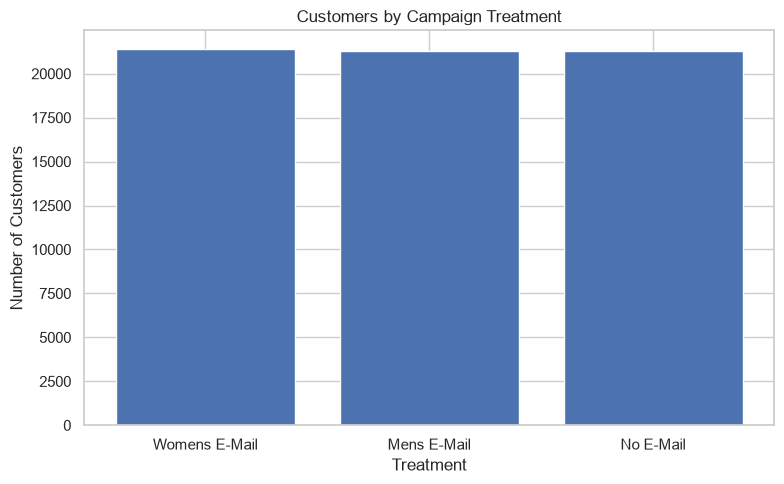

In [69]:
# ============================================================
# 8. TREATMENT DISTRIBUTION
# ============================================================

print(df["treatment"].value_counts())

print("\nTreatment percentages:")
print(
    df["treatment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


plt.figure(figsize=(8, 5))

treatment_counts = df["treatment"].value_counts()

plt.bar(
    treatment_counts.index,
    treatment_counts.values
)

plt.title("Customers by Campaign Treatment")
plt.xlabel("Treatment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Visit counts:
visit
0    54606
1     9394
Name: count, dtype: int64

Visit percentages:
visit
0    85.32
1    14.68
Name: proportion, dtype: float64


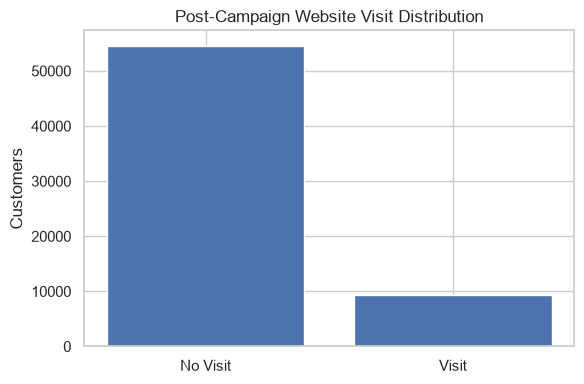

In [70]:
# ============================================================
# 9. VISIT OUTCOME DISTRIBUTION
# ============================================================

visit_counts = df["visit"].value_counts().sort_index()

print("Visit counts:")
print(visit_counts)

print("\nVisit percentages:")
print(
    df["visit"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

plt.figure(figsize=(6, 4))

plt.bar(
    ["No Visit", "Visit"],
    [
        (df["visit"] == 0).sum(),
        (df["visit"] == 1).sum()
    ]
)

plt.title("Post-Campaign Website Visit Distribution")
plt.ylabel("Customers")

plt.tight_layout()
plt.show()

Conversion counts:
conversion
0    63422
1      578
Name: count, dtype: int64

Conversion percentages:
conversion
0    99.097
1     0.903
Name: proportion, dtype: float64


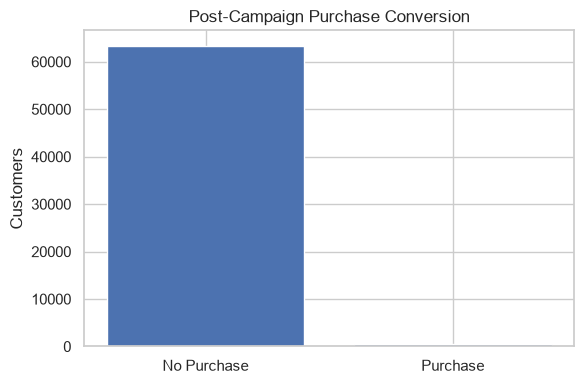

In [71]:
# ============================================================
# 10. CONVERSION OUTCOME DISTRIBUTION
# ============================================================

conversion_counts = df["conversion"].value_counts().sort_index()

print("Conversion counts:")
print(conversion_counts)

conversion_pct = (
    df["conversion"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print("\nConversion percentages:")
print(conversion_pct.round(3))

plt.figure(figsize=(6, 4))

plt.bar(
    ["No Purchase", "Purchase"],
    [
        (df["conversion"] == 0).sum(),
        (df["conversion"] == 1).sum()
    ]
)

plt.title("Post-Campaign Purchase Conversion")
plt.ylabel("Customers")

plt.tight_layout()
plt.show()

,customers,visits,visit_rate,visit_rate_pct
treatment,,,,
Mens E-Mail,21307,3894,0.182757,18.275684
No E-Mail,21306,2262,0.106167,10.616728
Womens E-Mail,21387,3238,0.151400,15.140038


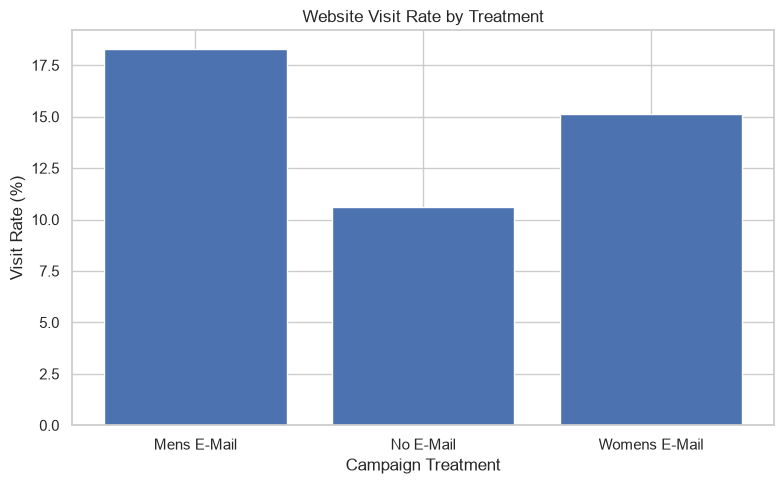

,customers,purchases,conversion_rate,conversion_rate_pct
treatment,,,,
Mens E-Mail,21307,267,0.012531,1.253109
No E-Mail,21306,122,0.005726,0.572609
Womens E-Mail,21387,189,0.008837,0.883714


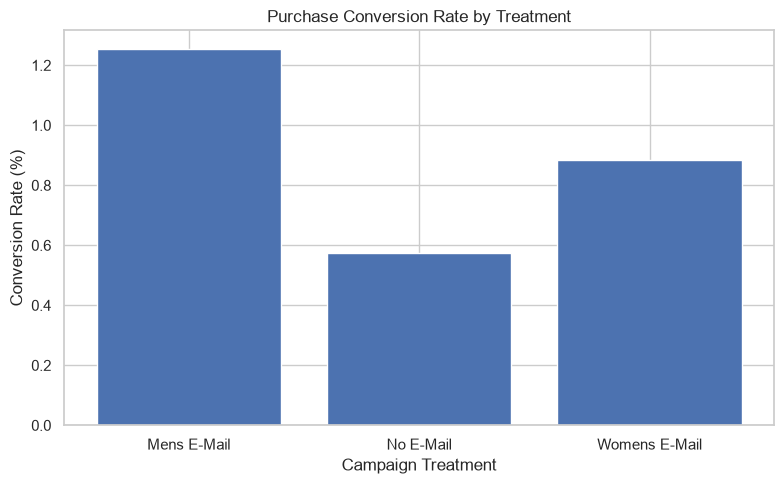

In [72]:
# ============================================================
# 11. OUTCOME RATES BY TREATMENT
# ============================================================

visit_by_treatment = (
    df.groupby("treatment")["visit"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "customers",
        "sum": "visits",
        "mean": "visit_rate"
    })
)

visit_by_treatment["visit_rate_pct"] = (
    visit_by_treatment["visit_rate"] * 100
)

display(visit_by_treatment)


plt.figure(figsize=(8, 5))

plot_data = (
    df.groupby("treatment")["visit"]
    .mean()
    .mul(100)
)

plt.bar(plot_data.index, plot_data.values)

plt.title("Website Visit Rate by Treatment")
plt.xlabel("Campaign Treatment")
plt.ylabel("Visit Rate (%)")

plt.tight_layout()
plt.show()


conversion_by_treatment = (
    df.groupby("treatment")["conversion"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "customers",
        "sum": "purchases",
        "mean": "conversion_rate"
    })
)

conversion_by_treatment["conversion_rate_pct"] = (
    conversion_by_treatment["conversion_rate"] * 100
)

display(conversion_by_treatment)


plt.figure(figsize=(8, 5))

plot_data = (
    df.groupby("treatment")["conversion"]
    .mean()
    .mul(100)
)

plt.bar(plot_data.index, plot_data.values)

plt.title("Purchase Conversion Rate by Treatment")
plt.xlabel("Campaign Treatment")
plt.ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.show()

In [73]:
# ============================================================
# 13. SPENDING BY TREATMENT
# ============================================================

spend_summary = (
    df.groupby("treatment")["spend"]
    .agg([
        "count",
        "mean",
        "median",
        "sum"
    ])
)

display(spend_summary)

converter_spend = (
    df[df["conversion"] == 1]
    .groupby("treatment")["spend"]
    .agg([
        "count",
        "mean",
        "median",
        "sum"
    ])
)

print("Spend among customers who purchased:")
display(converter_spend)

,count,mean,median,sum
treatment,,,,
Mens E-Mail,21307,1.422617,0.0,30311.69
No E-Mail,21306,0.652789,0.0,13908.33
Womens E-Mail,21387,1.077202,0.0,23038.11


Spend among customers who purchased:


,count,mean,median,sum
treatment,,,,
Mens E-Mail,267,113.526929,66.980,30311.69
No E-Mail,122,114.002705,88.365,13908.33
Womens E-Mail,189,121.894762,94.710,23038.11


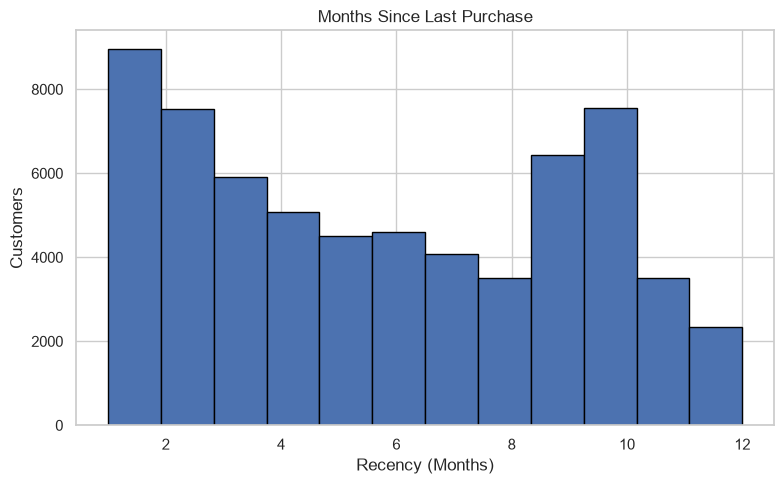

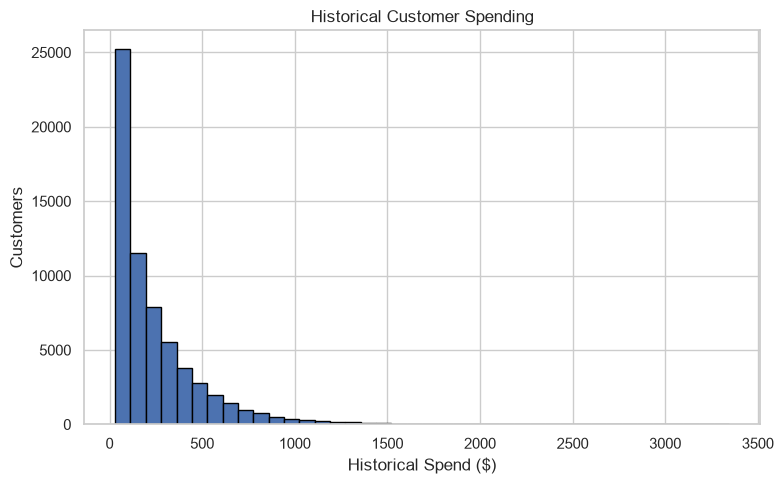

History skewness:
2.423796695859206

Spend skewness:
20.590558879357456


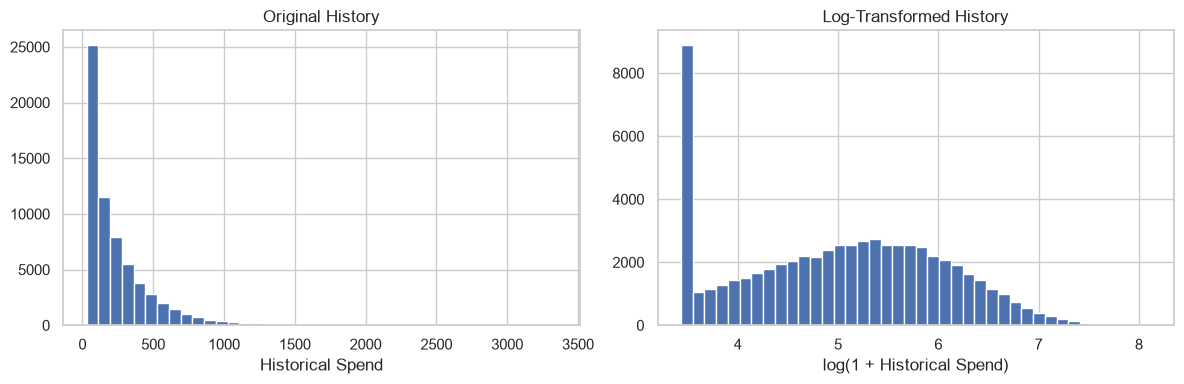

In [74]:
# ============================================================
# 14. NUMERIC FEATURE DISTRIBUTIONS
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    df["recency"],
    bins=12,
    edgecolor="black"
)

plt.title("Months Since Last Purchase")
plt.xlabel("Recency (Months)")
plt.ylabel("Customers")

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.hist(
    df["history"],
    bins=40,
    edgecolor="black"
)

plt.title("Historical Customer Spending")
plt.xlabel("Historical Spend ($)")
plt.ylabel("Customers")

plt.tight_layout()
plt.show()


print("History skewness:")
print(df["history"].skew())

print("\nSpend skewness:")
print(df["spend"].skew())


df["history_log1p"] = np.log1p(df["history"])


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["history"], bins=40)
axes[0].set_title("Original History")
axes[0].set_xlabel("Historical Spend")

axes[1].hist(df["history_log1p"], bins=40)
axes[1].set_title("Log-Transformed History")
axes[1].set_xlabel("log(1 + Historical Spend)")

plt.tight_layout()
plt.show()

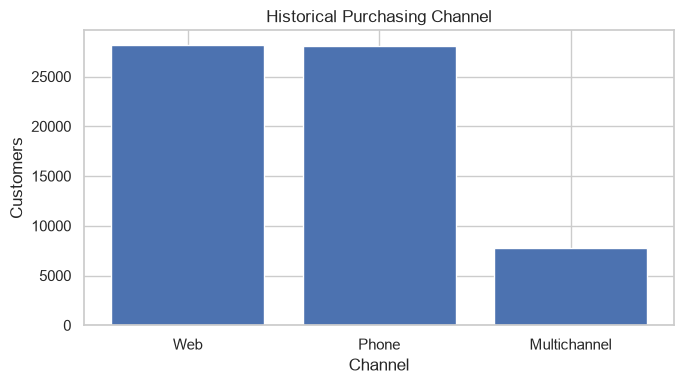

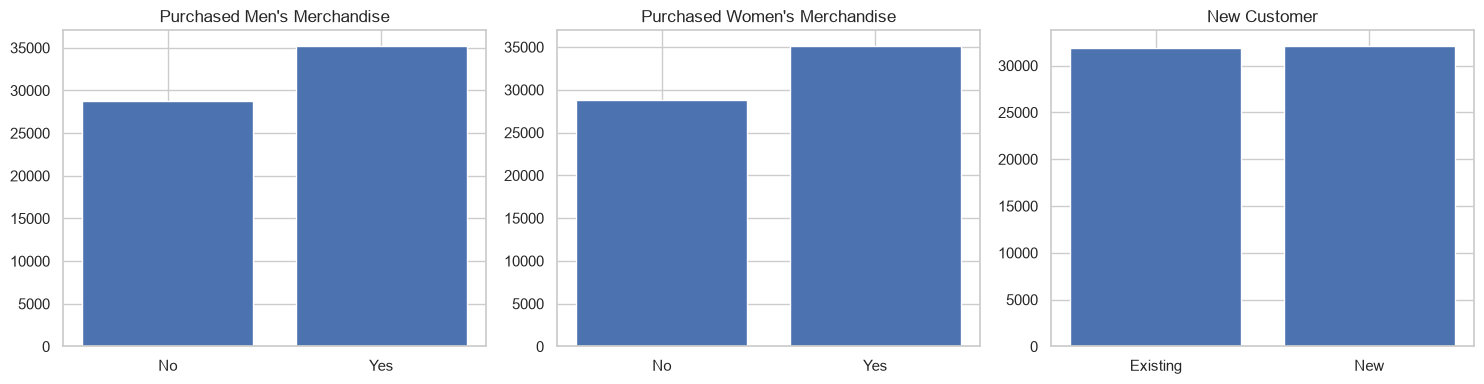

channel
Multichannel    1.262561
Web             0.932062
Phone           0.774419
Name: conversion, dtype: float64

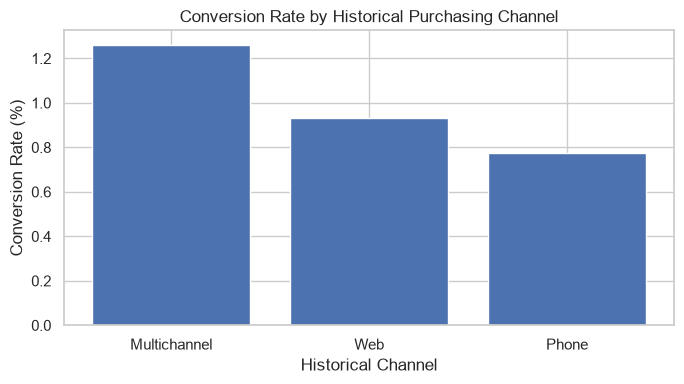

zip_code
Rural       1.118896
Suburban    0.830553
Urban       0.904096
Name: conversion, dtype: float64

Conversion rate by Men's purchase history and treatment:


treatment,Mens E-Mail,No E-Mail,Womens E-Mail
mens,,,
0,1.086957,0.514760,1.026226
1,1.388534,0.619326,0.766610


Conversion rate by Women's purchase history and treatment:


treatment,Mens E-Mail,No E-Mail,Womens E-Mail
womens,,,
0,1.150868,0.549907,0.613178
1,1.336284,0.591361,1.104972


treatment,Mens E-Mail,No E-Mail,Womens E-Mail
channel,,,
Multichannel,1.707412,0.690714,1.395890
Phone,1.082251,0.536078,0.708695
Web,1.296101,0.576123,0.919393


In [75]:
# ============================================================
# 16. CATEGORICAL CUSTOMER FEATURES
# ============================================================

plt.figure(figsize=(7, 4))

channel_counts = df["channel"].value_counts()

plt.bar(
    channel_counts.index,
    channel_counts.values
)

plt.title("Historical Purchasing Channel")
plt.xlabel("Channel")
plt.ylabel("Customers")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(
    ["No", "Yes"],
    df["mens"].value_counts().sort_index()
)
axes[0].set_title("Purchased Men's Merchandise")

axes[1].bar(
    ["No", "Yes"],
    df["womens"].value_counts().sort_index()
)
axes[1].set_title("Purchased Women's Merchandise")

axes[2].bar(
    ["Existing", "New"],
    df["newbie"].value_counts().sort_index()
)
axes[2].set_title("New Customer")

plt.tight_layout()
plt.show()

channel_conversion = (
    df.groupby("channel")["conversion"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

display(channel_conversion)

plt.figure(figsize=(7, 4))

plt.bar(
    channel_conversion.index,
    channel_conversion.values
)

plt.title("Conversion Rate by Historical Purchasing Channel")
plt.xlabel("Historical Channel")
plt.ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.show()


zip_conversion = (
    df.groupby("zip_code")["conversion"]
    .mean()
    .mul(100)
)

display(zip_conversion)


mens_response = (
    df.groupby(["mens", "treatment"])["conversion"]
    .mean()
    .mul(100)
    .unstack()
)

print("Conversion rate by Men's purchase history and treatment:")
display(mens_response)

womens_response = (
    df.groupby(["womens", "treatment"])["conversion"]
    .mean()
    .mul(100)
    .unstack()
)

print("Conversion rate by Women's purchase history and treatment:")
display(womens_response)


channel_response = (
    df.groupby(["channel", "treatment"])["conversion"]
    .mean()
    .mul(100)
    .unstack()
)

display(channel_response)

In [76]:
# ============================================================
# 20. RANDOMIZATION / TREATMENT BALANCE CHECK
# ============================================================

balance_numeric = (
    df.groupby("treatment")[
        [
            "recency",
            "history",
            "mens",
            "womens",
            "newbie"
        ]
    ]
    .mean()
    .round(3)
)

print("Average pre-treatment characteristics by treatment:")
display(balance_numeric)


print("Channel distribution by treatment:")

channel_balance = pd.crosstab(
    df["treatment"],
    df["channel"],
    normalize="index"
).mul(100).round(2)

display(channel_balance)

zip_balance = pd.crosstab(
    df["treatment"],
    df["zip_code"],
    normalize="index"
).mul(100).round(2)

display(zip_balance)


Average pre-treatment characteristics by treatment:


,recency,history,mens,womens,newbie
treatment,,,,,
Mens E-Mail,5.774,242.836,0.551,0.551,0.502
No E-Mail,5.750,240.883,0.553,0.548,0.502
Womens E-Mail,5.768,242.537,0.549,0.550,0.503


Channel distribution by treatment:


channel,Multichannel,Phone,Web
treatment,,,
Mens E-Mail,12.09,43.37,44.54
No E-Mail,12.23,43.78,43.99
Womens E-Mail,12.06,44.20,43.74


zip_code,Rural,Suburban,Urban
treatment,,,
Mens E-Mail,15.22,44.59,40.19
No E-Mail,14.73,45.18,40.09
Womens E-Mail,14.87,45.12,40.01


,recency,history,mens,womens,newbie,visit,conversion,spend
recency,1.000,-0.247,-0.031,-0.027,-0.052,-0.075,-0.024,-0.016
history,-0.247,1.000,0.113,0.115,0.223,0.065,0.029,0.022
mens,-0.031,0.113,1.000,-0.817,0.021,0.007,0.002,0.009
womens,-0.027,0.115,-0.817,1.000,0.021,0.052,0.013,0.002
newbie,-0.052,0.223,0.021,0.021,1.000,-0.074,-0.011,-0.008
visit,-0.075,0.065,0.007,0.052,-0.074,1.000,0.230,0.169
conversion,-0.024,0.029,0.002,0.013,-0.011,0.230,1.000,0.732
spend,-0.016,0.022,0.009,0.002,-0.008,0.169,0.732,1.000


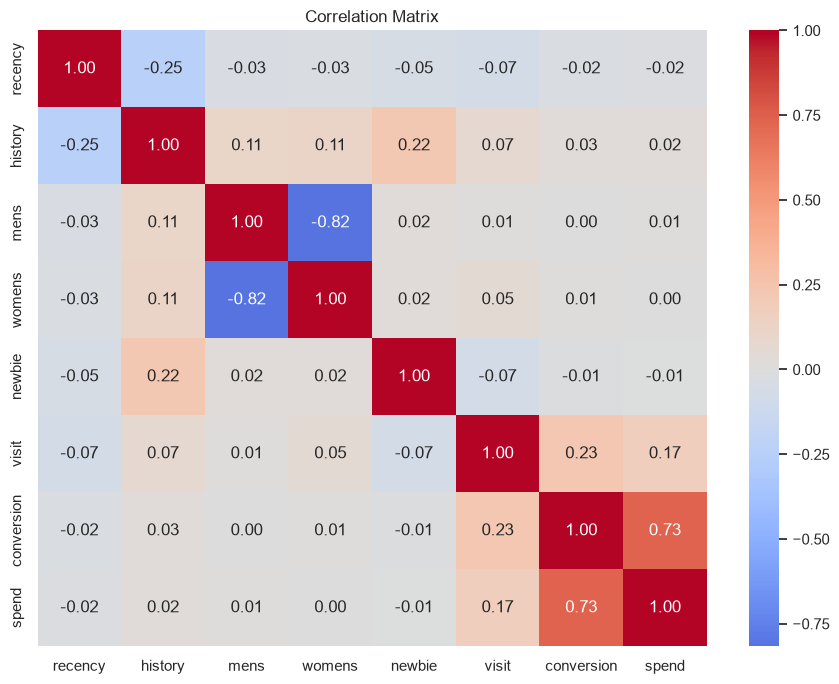

In [77]:
# ============================================================
# 21. CORRELATION ANALYSIS
# ============================================================

corr_columns = [
    "recency",
    "history",
    "mens",
    "womens",
    "newbie",
    "visit",
    "conversion",
    "spend"
]

correlation_matrix = df[corr_columns].corr()

display(correlation_matrix.round(3))

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [78]:
# ============================================================
# 22. DEFINE PRE-CAMPAIGN FEATURES
# ============================================================

numeric_features = [
    "recency",
    "history"
]

binary_features = [
    "mens",
    "womens",
    "newbie"
]

categorical_features = [
    "zip_code",
    "channel"
]

In [79]:
# ============================================================
# 23. GENERAL-PURPOSE MISSING-VALUE IMPUTATION
# ============================================================

# Create modeling copy
model_df = df.copy()

# Numeric features -> median
for col in numeric_features:
    model_df[col] = model_df[col].fillna(
        model_df[col].median()
    )

# Binary features -> mode
for col in binary_features:
    model_df[col] = model_df[col].fillna(
        model_df[col].mode()[0]
    )

# Categorical features -> mode
for col in categorical_features:
    model_df[col] = model_df[col].fillna(
        model_df[col].mode()[0]
    )

print("Remaining missing values:")
print(
    model_df[
        numeric_features +
        binary_features +
        categorical_features
    ].isnull().sum()
)

Remaining missing values:
recency     0
history     0
mens        0
womens      0
newbie      0
zip_code    0
channel     0
dtype: int64


In [80]:
# ============================================================
# 24. CREATE MODELING FEATURE SET
# ============================================================

feature_columns = [
    "recency",
    "history",
    "mens",
    "womens",
    "newbie",
    "zip_code",
    "channel"
]

X_model = model_df[feature_columns].copy()

# Outcomes
y_visit = model_df["visit"].copy()
y_conversion = model_df["conversion"].copy()
y_spend = model_df["spend"].copy()

# Treatment
treatment = model_df["treatment"].copy()

print("X_model shape:", X_model.shape)
print("y_conversion shape:", y_conversion.shape)
print("Treatment shape:", treatment.shape)

display(X_model.head())

X_model shape: (64000, 7)
y_conversion shape: (64000,)
Treatment shape: (64000,)


,recency,history,mens,womens,newbie,zip_code,channel
0,10,142.44,1,0,0,Suburban,Phone
1,6,329.08,1,1,1,Rural,Web
2,7,180.65,0,1,1,Suburban,Web
3,9,675.83,1,0,1,Rural,Web
4,2,45.34,1,0,0,Urban,Web


In [81]:
# ============================================================
# 25. SEGMENTATION FEATURES
# ============================================================

segmentation_df = model_df[
    [
        "recency",
        "history",
        "mens",
        "womens",
        "newbie",
        "zip_code",
        "channel"
    ]
].copy()

# Reduce skew in spending
segmentation_df["history_log1p"] = np.log1p(
    segmentation_df["history"]
)

# We now use log history rather than raw history
segmentation_df.drop(
    columns="history",
    inplace=True
)

display(segmentation_df.head())

,recency,mens,womens,newbie,zip_code,channel,history_log1p
0,10,1,0,0,Suburban,Phone,4.965917
1,6,1,1,1,Rural,Web,5.799335
2,7,0,1,1,Suburban,Web,5.202082
3,9,1,0,1,Rural,Web,6.517420
4,2,1,0,0,Urban,Web,3.836006


In [83]:
# ============================================================
# 26. ENCODE / SCALE SEGMENTATION FEATURES
# ============================================================

seg_numeric = [
    "recency",
    "history_log1p",
    "mens",
    "womens",
    "newbie"
]

seg_categorical = [
    "zip_code",
    "channel"
]

seg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            seg_numeric
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            seg_categorical
        )
    ]
)

X_cluster = seg_preprocessor.fit_transform(
    segmentation_df
)

print("Cluster feature matrix shape:")
print(X_cluster.shape)


cluster_feature_names = (
    seg_preprocessor
    .get_feature_names_out()
)

print(cluster_feature_names)


X_cluster_df = pd.DataFrame(
    X_cluster,
    columns=cluster_feature_names,
    index=segmentation_df.index
)

display(X_cluster_df.head())

Cluster feature matrix shape:
(64000, 11)
['numeric__recency' 'numeric__history_log1p' 'numeric__mens'
 'numeric__womens' 'numeric__newbie' 'categorical__zip_code_Rural'
 'categorical__zip_code_Suburban' 'categorical__zip_code_Urban'
 'categorical__channel_Multichannel' 'categorical__channel_Phone'
 'categorical__channel_Web']


,numeric__recency,numeric__history_log1p,numeric__mens,numeric__womens,numeric__newbie,categorical__zip_code_Rural,categorical__zip_code_Suburban,categorical__zip_code_Urban,categorical__channel_Multichannel,categorical__channel_Phone,categorical__channel_Web
0,1.207751,-0.039967,0.902651,-1.104914,-1.00451,0.0,1.0,0.0,0.0,1.0,0.0
1,0.067359,0.777717,0.902651,0.905048,0.99551,1.0,0.0,0.0,0.0,0.0,1.0
2,0.352457,0.191739,-1.107848,0.905048,0.99551,0.0,1.0,0.0,0.0,0.0,1.0
3,0.922653,1.482244,0.902651,-1.104914,0.99551,1.0,0.0,0.0,0.0,0.0,1.0
4,-1.073034,-1.148546,0.902651,-1.104914,-1.00451,0.0,0.0,1.0,0.0,0.0,1.0


In [84]:
# ============================================================
# 27. PREPROCESSOR FOR SUPERVISED / UPLIFT MODELS
# ============================================================

model_numeric = [
    "recency",
    "history"
]

model_binary = [
    "mens",
    "womens",
    "newbie"
]

model_categorical = [
    "zip_code",
    "channel"
]

model_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            model_numeric
        ),
        (
            "binary",
            "passthrough",
            model_binary
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            model_categorical
        )
    ]
)

X_encoded = model_preprocessor.fit_transform(
    X_model
)

encoded_feature_names = (
    model_preprocessor
    .get_feature_names_out()
)

X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=encoded_feature_names,
    index=X_model.index
)

print("Encoded modeling data shape:")
print(X_encoded_df.shape)

display(X_encoded_df.head())

Encoded modeling data shape:
(64000, 11)


,numeric__recency,numeric__history,binary__mens,binary__womens,binary__newbie,categorical__zip_code_Rural,categorical__zip_code_Suburban,categorical__zip_code_Urban,categorical__channel_Multichannel,categorical__channel_Phone,categorical__channel_Web
0,1.207751,-0.389003,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.067359,0.339614,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.352457,-0.239836,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.922653,1.693278,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
4,-1.073034,-0.768068,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [85]:
# ============================================================
# 28. FINAL DATA SUMMARY
# ============================================================

print("=" * 60)
print("HILLSTROM PROJECT DATA SUMMARY")
print("=" * 60)

print(f"Customers:             {len(df):,}")
print(f"Historical features:   {len(feature_columns)}")
print(f"Treatment groups:      {df['treatment'].nunique()}")

print("\nTreatment Groups:")
for treatment_name, count in df["treatment"].value_counts().items():
    pct = count / len(df) * 100
    print(
        f"  {treatment_name:<18} "
        f"{count:>6,} ({pct:5.2f}%)"
    )

print("\nOutcomes:")

visit_rate = df["visit"].mean() * 100
conversion_rate = df["conversion"].mean() * 100
average_spend = df["spend"].mean()

print(f"  Visit Rate:          {visit_rate:.2f}%")
print(f"  Conversion Rate:     {conversion_rate:.2f}%")
print(f"  Average Spend:       ${average_spend:.2f}")

print("\nData Quality:")
print(
    f"  Missing Values:      "
    f"{df.isnull().sum().sum():,}"
)

print(
    f"  Exact Duplicate Rows:"
    f" {df.duplicated().sum():,}"
)

print("\nPrepared Objects:")
print(f"  X_model:             {X_model.shape}")
print(f"  X_encoded_df:        {X_encoded_df.shape}")
print(f"  X_cluster_df:        {X_cluster_df.shape}")

print("=" * 60)

HILLSTROM PROJECT DATA SUMMARY
Customers:             64,000
Historical features:   7
Treatment groups:      3

Treatment Groups:
  Womens E-Mail      21,387 (33.42%)
  Mens E-Mail        21,307 (33.29%)
  No E-Mail          21,306 (33.29%)

Outcomes:
  Visit Rate:          14.68%
  Conversion Rate:     0.90%
  Average Spend:       $1.05

Data Quality:
  Missing Values:      0
  Exact Duplicate Rows: 6,562

Prepared Objects:
  X_model:             (64000, 7)
  X_encoded_df:        (64000, 11)
  X_cluster_df:        (64000, 11)
